# 1. NOTEARS-MLP・Sobの実装と動作確認

In [3]:
import os

os.chdir('/home/hashikami/projects/Diff')

In [2]:
import torch
import numpy as np
from notears.nonlinear import NotearsMLP, NotearsSobolev, notears_nonlinear
from notears.linear import notears_linear



torch.set_default_dtype(torch.double)
np.set_printoptions(precision=3)

import notears.utils as ut
ut.set_random_seed(123)

n, d, s0, graph_type, sem_type = 200, 5, 9, 'ER', 'mim'
B_true = ut.simulate_dag(d, s0, graph_type)
W_true = ut.simulate_parameter(B_true) # tanhケースを用いる場合

# X = ut.simulate_nonlinear_sem2(B_true, n, sem_type)
gamma = 3.0 * np.ones(d) # tanhケースを用いる場合
X = ut.simulate_nonlinear_sem(W_true, gamma, n, sem_type='tanh') # tanhケースを用いる場合

model = NotearsMLP(dims=[d, 100, 1], bias=True)
# model = NotearsSobolev(d, 10)
W_est = notears_nonlinear(model, X, lambda1=0.01, lambda2=0.01, w_threshold=0.3)
W_est_linear = notears_linear(X, 0.1, loss_type='l2', w_threshold=0.3)
assert ut.is_dag(W_est)
assert ut.is_dag(W_est_linear)

acc = ut.count_accuracy(B_true, W_est != 0)
acc_linear = ut.count_accuracy(B_true, W_est_linear != 0)
print(acc)
print(acc_linear)

/home/hashikami/projects/Diff/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'fdr': 0.25, 'tpr': 0.6666666666666666, 'fpr': 2.0, 'shd': 4, 'nnz': 8}
{'fdr': 0.14285714285714285, 'tpr': 0.6666666666666666, 'fpr': 1.0, 'shd': 4, 'nnz': 7}


動作確認完了。

# 2. 定量評価：非線形ケースに対してcareflと連携して学習しnotears-linearと性能比較

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_nll_vs_nodes(
    csv_path: str,
    savepath: str = None,
    nodes_order=(10, 20, 50, 100),
    # 必要に応じて同一条件でフィルタ（複数CSVをまとめた時の混在対策）
    filter_params=None,  # 例: {"n":10000, "gamma_scale":1.0, "s0_scale":2.0, "lambda":0.01}
):
    """
    CSV 形式（カラムはユーザ記載どおり）から1枚の折れ線グラフを描画。
    - y: neg_log_likelihood_per_dim
    - x: n_nodes
    - 4系列: true model / carefl(notears-linear / notears-mlp / notears-sob)
    """
    df = pd.read_csv(csv_path)

    # 任意の条件でフィルタ
    if filter_params:
        for k, v in filter_params.items():
            if k in df.columns:
                df = df[df[k] == v]

    # 型をそろえる
    df["n_nodes"] = df["n_nodes"].astype(int)
    df["neg_log_likelihood_per_dim"] = df["neg_log_likelihood_per_dim"].astype(float)

    # 系列定義
    series_specs = [
        # (label, row selector)
        ("true model", (df["model"] == "true model") & (df["notears_type"] == "unused")),
        ("carefl (notears-linear)", (df["model"] == "carefl") & (df["notears_type"] == "notears-linear")),
        ("carefl (notears-mlp)",   (df["model"] == "carefl") & (df["notears_type"] == "notears-mlp")),
        ("carefl (notears-sob)",   (df["model"] == "carefl") & (df["notears_type"] == "notears-sob")),
    ]
    colors = {
        "true model": "black",
        "carefl (notears-linear)": "tab:red",
        "carefl (notears-mlp)": "tab:green",
        "carefl (notears-sob)": "tab:blue",
    }

    # 集計（シードが複数なら平均）
    def aggregate(sel):
        sub = df[sel].copy()
        if sub.empty:
            return None
        g = sub.groupby("n_nodes")["neg_log_likelihood_per_dim"]
        mean = g.mean()
        # ci = 1.96 * g.std(ddof=1) / np.sqrt(g.count())  # 95%CI（帯表示したい場合に使用）
        return mean

    plt.figure(figsize=(7, 4.5))
    y_values_all = []

    for label, selector in series_specs:
        agg = aggregate(selector)
        if agg is None or agg.empty:
            continue
        # nodes_order に従って並べる（欠損は落とす）
        x = []
        y = []
        for d in nodes_order:
            if d in agg.index:
                x.append(d)
                y.append(agg.loc[d])
        if len(x) == 0:
            continue
        y_values_all.extend(y)
        plt.plot(x, y, marker="o", linewidth=2, label=label, color=colors.get(label, None))
        # CIを描きたい場合（上でciを返すように拡張してから使用）
        # plt.fill_between(x, (y-ci_vals), (y+ci_vals), alpha=0.15, color=colors.get(label, None))

    # 体裁
    plt.xlabel("Number of nodes (d)")
    plt.ylabel("Negative log-likelihood / dim")
    plt.xticks(list(nodes_order))
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="best")

    # すべての系列が同一スケールで比較できるように y 範囲を共通化
    if y_values_all:
        ymin, ymax = min(y_values_all), max(y_values_all)
        pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
        # plt.ylim(ymin - pad, ymax + pad)
        plt.ylim(1.3, 2.0)

    title_bits = []
    if filter_params:
        for k in ["n", "gamma_scale", "s0_scale", "lambda", "w_threshold", "nh", "num_expansion"]:
            if k in (filter_params or {}) and k in df.columns:
                title_bits.append(f"{k}={filter_params[k]}")
    if title_bits:
        plt.title("NLL per dim across notears variants  |  " + ", ".join(title_bits))
    else:
        plt.title("NLL per dim across notears variants")

    plt.tight_layout()

    if savepath:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()


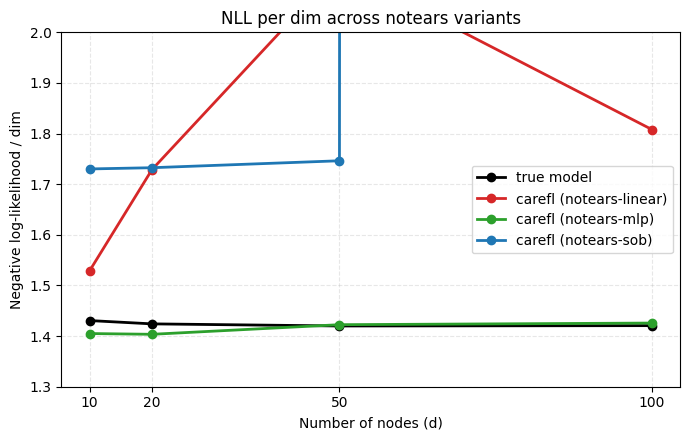

In [15]:
# plot_nll_vs_nodes(
#     csv_path="results/carefl_evaluate/carefl_eval_tanh_n1024_gamma3.0_s02.0_lam0.01_thr0.3_nh10_sob10_20250924-085908.csv",
#     nodes_order=(10, 20, 50, 100),
#     filter_params={"n":1024, "gamma_scale":3.0, "s0_scale":2.0, "lambda":0.01, "w_threshold":0.3, "nh":10, "num_expansion":10},
# )

plot_nll_vs_nodes(
    csv_path="results/carefl_evaluate/carefl_eval_tanh_n1024_gamma3.0_s02.0_lam0.01_thr0.3_nh10_sob10_20250924-085908.csv",
    nodes_order=(10, 20, 50, 100),
    filter_params=None,
)